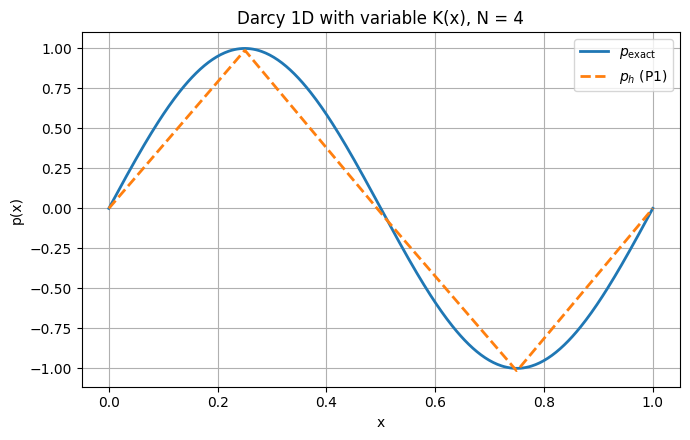

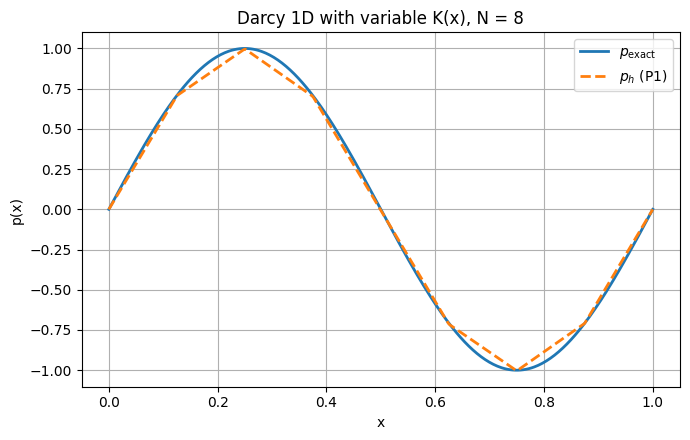

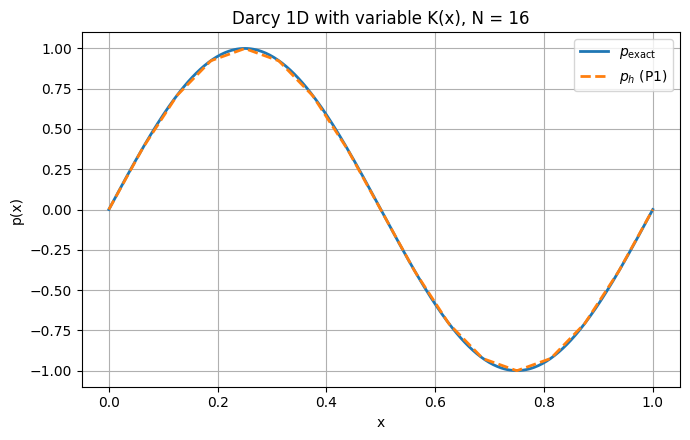

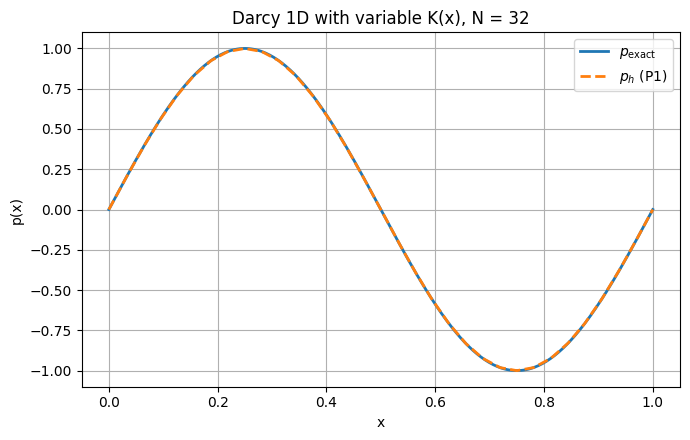

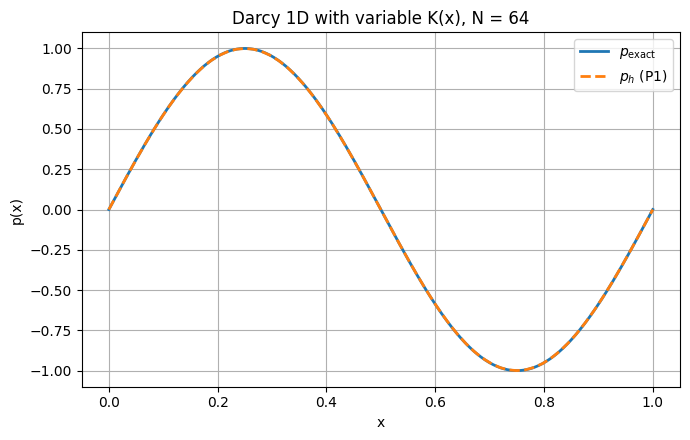

       N            h         ||e||_L2     rate(L2)           |e|_H1     rate(H1)
----------------------------------------------------------------------------------
       4 2.500000e-01   1.50463757e-01          ---   1.93460567e+00          ---
       8 1.250000e-01   3.92085750e-02     1.940175   9.97138754e-01     0.956173
      16 6.250000e-02   9.90313092e-03     1.985213   5.02379059e-01     0.989018
      32 3.125000e-02   2.48211910e-03     1.996312   2.51668266e-01     0.997253
      64 1.562500e-02   6.20926189e-04     1.999079   1.25894054e-01     0.999313


In [6]:
from mpi4py import MPI
from petsc4py import PETSc
import numpy as np
from math import log
import matplotlib.pyplot as plt
import math

from dolfinx import fem, mesh, geometry
from dolfinx.fem.petsc import LinearProblem
import ufl


def exact_p_array(x):
    # x has shape (gdim, num_points)
    return np.sin(2 * np.pi * x[0])


def solve_darcy_1d(ncells: int):
    """
    Solve
        -(K(x) p')' = f  on (0,1),
    with
        K(x) = 2 + x^2,
        p_exact(x) = sin(2*pi*x),
        f(x) = 4*pi^2*(2 + x^2)*sin(2*pi*x) - 4*pi*x*cos(2*pi*x).
    """
    comm = MPI.COMM_WORLD

    # Mesh
    domain = mesh.create_interval(comm, ncells, [0.0, 1.0])

    # P2 space
    V = fem.functionspace(domain, ("Lagrange", 1))

    # Trial and test functions
    p = ufl.TrialFunction(V)
    v = ufl.TestFunction(V)

    x = ufl.SpatialCoordinate(domain)

    # Variable permeability
    K = 2.0 + x[0] ** 2

    # Exact forcing for p_exact = sin(2*pi*x)
    f = (
        4 * math.pi**2 * (2.0 + x[0] ** 2) * ufl.sin(2 * math.pi * x[0])
        - 4 * math.pi * x[0] * ufl.cos(2 * math.pi * x[0])
    )

    # Weak form: ∫ K p' v' dx = ∫ f v dx
    a = K * ufl.inner(ufl.grad(p), ufl.grad(v)) * ufl.dx
    L = f * v * ufl.dx

    # Boundary markers
    def left_boundary(x):
        return np.isclose(x[0], 0.0)

    def right_boundary(x):
        return np.isclose(x[0], 1.0)

    left_dofs = fem.locate_dofs_geometrical(V, left_boundary)
    right_dofs = fem.locate_dofs_geometrical(V, right_boundary)

    # p_exact(0)=0 and p_exact(1)=0
    p_left = fem.Constant(domain, PETSc.ScalarType(0.0))
    p_right = fem.Constant(domain, PETSc.ScalarType(0.0))

    bc_left = fem.dirichletbc(p_left, left_dofs, V)
    bc_right = fem.dirichletbc(p_right, right_dofs, V)
    bcs = [bc_left, bc_right]

    # Solve
    problem = LinearProblem(
        a,
        L,
        bcs=bcs,
        petsc_options_prefix=f"darcy1d_{ncells}_",
        petsc_options={
            "ksp_type": "preonly",
            "pc_type": "lu",
        },
    )

    ph = problem.solve()
    ph.name = "p_h"

    # Higher-order space for error computation
    W = fem.functionspace(domain, ("Lagrange", 4))

    p_exact_h = fem.Function(W)
    p_exact_h.interpolate(exact_p_array)

    ph_high = fem.Function(W)
    ph_high.interpolate(ph)

    # L2 error
    e_L2_form = fem.form((ph_high - p_exact_h) ** 2 * ufl.dx)
    e_L2 = np.sqrt(comm.allreduce(fem.assemble_scalar(e_L2_form), op=MPI.SUM))

    # H1 seminorm error
    e_H1_form = fem.form(
        ufl.inner(ufl.grad(ph_high - p_exact_h), ufl.grad(ph_high - p_exact_h)) * ufl.dx
    )
    e_H1 = np.sqrt(comm.allreduce(fem.assemble_scalar(e_H1_form), op=MPI.SUM))

    h = 1.0 / ncells
    return domain, ph, h, e_L2, e_H1


def convergence_rate(errors, hs):
    rates = [None]
    for i in range(1, len(errors)):
        r = log(errors[i - 1] / errors[i]) / log(hs[i - 1] / hs[i])
        rates.append(r)
    return rates


def plot_solution(domain, ph, ncells):
    """
    Plot p_h and p_exact on a fine set of points in [0,1].
    """
    comm = domain.comm
    rank = comm.rank

    # Fine plotting points
    x_plot = np.linspace(0.0, 1.0, 400, dtype=np.float64)
    points = np.zeros((len(x_plot), 3), dtype=np.float64)
    points[:, 0] = x_plot

    # Locate cells containing the points
    tree = geometry.bb_tree(domain, domain.topology.dim)
    cell_candidates = geometry.compute_collisions_points(tree, points)
    colliding_cells = geometry.compute_colliding_cells(domain, cell_candidates, points)

    points_on_proc = []
    cells = []
    x_local = []

    for i, point in enumerate(points):
        cell_list = colliding_cells.links(i)
        if len(cell_list) > 0:
            points_on_proc.append(point)
            cells.append(cell_list[0])
            x_local.append(x_plot[i])

    points_on_proc = np.array(points_on_proc, dtype=np.float64)
    x_local = np.array(x_local, dtype=np.float64)

    if len(points_on_proc) > 0:
        ph_vals_local = ph.eval(points_on_proc, cells).flatten()
        # pexact_vals_local = x_local * (1.0 - x_local)
        pexact_vals_local = np.sin(2*math.pi*x_local)
    else:
        ph_vals_local = np.array([], dtype=np.float64)
        pexact_vals_local = np.array([], dtype=np.float64)

    gathered_x = comm.gather(x_local, root=0)
    gathered_ph = comm.gather(ph_vals_local, root=0)
    gathered_pe = comm.gather(pexact_vals_local, root=0)

    if rank == 0:
        x_all = np.concatenate(gathered_x)
        ph_all = np.concatenate(gathered_ph)
        pe_all = np.concatenate(gathered_pe)

        idx = np.argsort(x_all)
        x_all = x_all[idx]
        ph_all = ph_all[idx]
        pe_all = pe_all[idx]

        plt.figure(figsize=(7, 4.5))
        plt.plot(x_all, pe_all, label=r"$p_{\mathrm{exact}}$", linewidth=2)
        plt.plot(x_all, ph_all, "--", label=r"$p_h$ (P1)", linewidth=2)
        plt.xlabel("x")
        plt.ylabel("p(x)")
        plt.title(f"Darcy 1D with variable K(x), N = {ncells}")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()


if __name__ == "__main__":
    mesh_sizes = [4, 8, 16, 32, 64]

    hs = []
    L2_errors = []
    H1_errors = []

    for n in mesh_sizes:
        domain, ph, h, eL2, eH1 = solve_darcy_1d(n)

        hs.append(h)
        L2_errors.append(eL2)
        H1_errors.append(eH1)

        # Plot p_h and p_exact for each mesh
        plot_solution(domain, ph, n)

    L2_rates = convergence_rate(L2_errors, hs)
    H1_rates = convergence_rate(H1_errors, hs)

    if MPI.COMM_WORLD.rank == 0:
        print(f"{'N':>8} {'h':>12} {'||e||_L2':>16} {'rate(L2)':>12} {'|e|_H1':>16} {'rate(H1)':>12}")
        print("-" * 82)
        for i, n in enumerate(mesh_sizes):
            rL2 = "---" if L2_rates[i] is None else f"{L2_rates[i]:.6f}"
            rH1 = "---" if H1_rates[i] is None else f"{H1_rates[i]:.6f}"
            print(
                f"{n:8d} {hs[i]:12.6e} {L2_errors[i]:16.8e} {rL2:>12} "
                f"{H1_errors[i]:16.8e} {rH1:>12}"
            )

N = 32
h = 0.03125
L2 error  = 2.482119e-03
H1 error  = 2.516683e-01
Number of flux sample points = 96
[epoch   1000] loss=9.456349e+02, data=1.146176e+02, phys=8.310173e+02
[epoch   2000] loss=5.144878e+02, data=1.134917e+02, phys=4.009961e+02
[epoch   3000] loss=2.956157e+02, data=1.005764e+02, phys=1.950393e+02
[epoch   4000] loss=1.766806e+02, data=9.093374e+01, phys=8.574690e+01
[epoch   5000] loss=1.162113e+02, data=8.192157e+01, phys=3.428977e+01
[epoch   6000] loss=8.614801e+01, data=7.158704e+01, phys=1.456097e+01
[epoch   7000] loss=6.773531e+01, data=5.957301e+01, phys=8.162309e+00
[epoch   8000] loss=5.337373e+01, data=4.768008e+01, phys=5.693656e+00
[epoch   9000] loss=4.131032e+01, data=3.706332e+01, phys=4.247001e+00
[epoch  10000] loss=3.111692e+01, data=2.795163e+01, phys=3.165288e+00
[epoch  11000] loss=2.264606e+01, data=2.030937e+01, phys=2.336686e+00
[epoch  12000] loss=1.578610e+01, data=1.409570e+01, phys=1.690400e+00
[epoch  13000] loss=1.042299e+01, data=9.2537

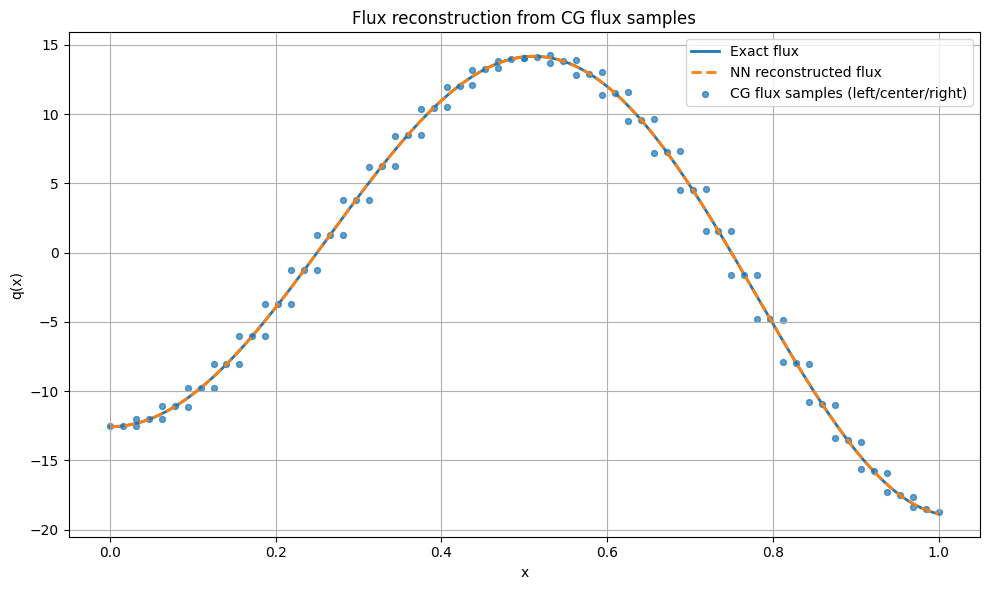

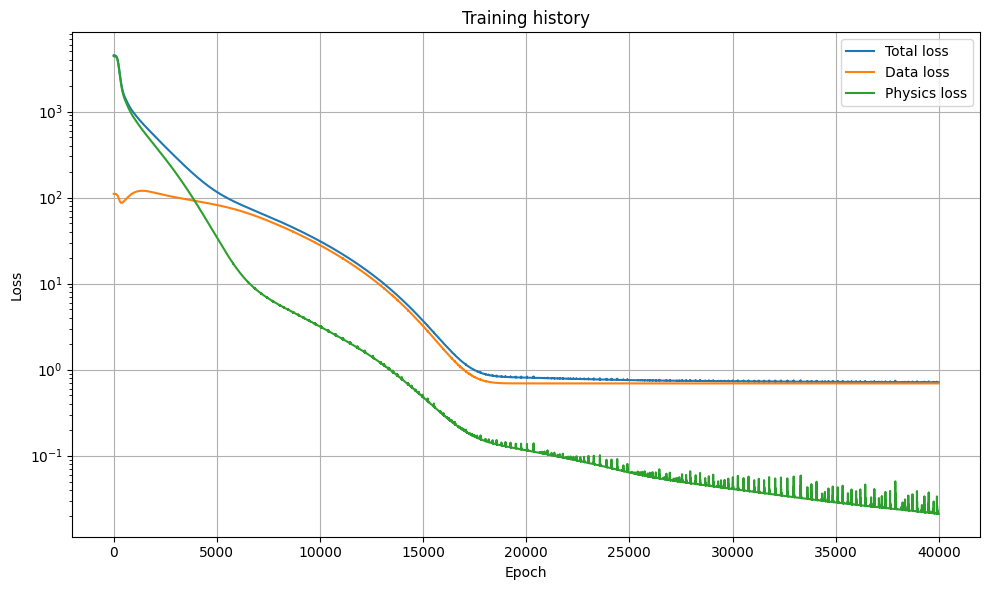

In [7]:
from mpi4py import MPI
from petsc4py import PETSc
import numpy as np
from math import log
import matplotlib.pyplot as plt
import math
import torch
import torch.nn as nn

from dolfinx import fem, mesh
from dolfinx.fem.petsc import LinearProblem
import ufl


# ============================================================
# Exact solution / forcing
# ============================================================

def exact_p_array(x):
    # x has shape (gdim, num_points)
    return np.sin(2 * np.pi * x[0])


def exact_q_array(x):
    # q = -K p' = -(2 + x^2) * 2*pi*cos(2*pi x)
    return -(2.0 + x[0] ** 2) * (2.0 * np.pi * np.cos(2.0 * np.pi * x[0]))


def forcing_np(x):
    """
    f(x) = -(K p')' with p_exact = sin(2*pi*x), K = 2 + x^2
         = 4*pi^2*(2 + x^2)*sin(2*pi*x) - 4*pi*x*cos(2*pi*x)
    x is a numpy array
    """
    return (
        4.0 * np.pi**2 * (2.0 + x**2) * np.sin(2.0 * np.pi * x)
        - 4.0 * np.pi * x * np.cos(2.0 * np.pi * x)
    )


def forcing_torch(x):
    """
    same as forcing_np but for torch tensor x of shape (N,1)
    """
    return (
        4.0 * math.pi**2 * (2.0 + x**2) * torch.sin(2.0 * math.pi * x)
        - 4.0 * math.pi * x * torch.cos(2.0 * math.pi * x)
    )

# ============================================================
# Extract CG flux data: 3 points per element
# ============================================================

def extract_flux_samples_1d(domain, ph, sample_points_ref=None):
    """
    Generalized flux sampler for 1D CG(Lagrange, k).

    For each cell K, sample the FE flux
        q_h(x) = -K(x) p_h'(x)
    at points inside that cell.

    Parameters
    ----------
    domain : dolfinx.mesh.Mesh
        1D interval mesh
    ph : dolfinx.fem.Function
        Scalar CG solution
    sample_points_ref : array-like, optional
        Reference-cell sample points in [0, 1].
        Default: [0.0, 0.5, 1.0]  (left, center, right)

    Returns
    -------
    x_samples : np.ndarray
        Physical sample locations, shape (num_cells_global * npts,)
    q_samples : np.ndarray
        Flux values at those points, shape (num_cells_global * npts,)

    Notes
    -----
    - Assumes a scalar Lagrange space on a 1D interval mesh.
    - Keeps duplicated interface points from neighboring cells, so the
      discontinuity of the CG flux is preserved in the sampled data.
    """

    if sample_points_ref is None:
        sample_points_ref = np.array([0.0, 0.5, 1.0], dtype=np.float64)
    else:
        sample_points_ref = np.asarray(sample_points_ref, dtype=np.float64)

    comm = domain.comm
    V = ph.function_space

    # Basic checks
    tdim = domain.topology.dim
    gdim = domain.geometry.dim
    if tdim != 1 or gdim != 1:
        raise ValueError("This function is written for 1D interval meshes only.")

    # Create cell -> vertex connectivity
    domain.topology.create_connectivity(tdim, 0)

    # Local/global data
    dof_coords = V.tabulate_dof_coordinates()[:, 0]
    pvals = ph.x.array
    num_cells_local = domain.topology.index_map(tdim).size_local

    # Get the Basix element behind the dolfinx space
    element = V.element.basix_element

    # Reference points for Basix tabulation must have shape (npts, tdim)
    Xref = sample_points_ref.reshape(-1, 1)

    # Tabulate basis functions and first derivatives on the reference cell
    #
    # tab[0, :, :, 0] = basis values
    # tab[1, :, :, 0] = dphi/dxi on reference interval
    #
    # Shape is typically:
    #   (nderivs, npts, ndofs, value_size)
    tab = element.tabulate(1, Xref)

    # For scalar Lagrange in 1D:
    # reference derivatives dphi/dxi at requested sample points
    dphi_dxi = tab[1, :, :, 0]   # shape (npts, ndofs)

    x_local = []
    q_local = []

    for cell in range(num_cells_local):
        cell_dofs = V.dofmap.cell_dofs(cell)

        # Coordinates of the dofs that live on this cell
        x_dofs = dof_coords[cell_dofs]
        p_dofs = pvals[cell_dofs]

        # Cell endpoints from all local dof coordinates
        xL = np.min(x_dofs)
        xR = np.max(x_dofs)
        J = xR - xL

        if J <= 0.0:
            raise RuntimeError(f"Non-positive cell Jacobian detected on cell {cell}.")

        # Map reference points xi in [0,1] to physical points x = xL + J*xi
        x_phys = xL + J * sample_points_ref

        # FE derivative on the physical cell:
        #   dp/dx = sum_j p_j * dphi_j/dx
        #         = sum_j p_j * (dphi_j/dxi) / J
        dpdx = (dphi_dxi @ p_dofs) / J

        # Flux q_h = -K(x) p_h'(x)
        Kpts = 2.0 + x_phys**2
        qpts = -Kpts * dpdx

        x_local.append(x_phys)
        q_local.append(qpts)

    if len(x_local) == 0:
        x_local = np.empty((0,), dtype=np.float64)
        q_local = np.empty((0,), dtype=np.float64)
    else:
        x_local = np.concatenate(x_local)
        q_local = np.concatenate(q_local)

    # Gather to all ranks
    x_all = comm.allgather(x_local)
    q_all = comm.allgather(q_local)

    x_samples = np.concatenate(x_all) if len(x_all) > 0 else np.empty((0,), dtype=np.float64)
    q_samples = np.concatenate(q_all) if len(q_all) > 0 else np.empty((0,), dtype=np.float64)

    # Sort by x for nicer plotting / training reproducibility
    perm = np.argsort(x_samples)
    x_samples = x_samples[perm]
    q_samples = q_samples[perm]

    return x_samples, q_samples


# ============================================================
# Neural network for repaired flux
# ============================================================

class FluxNet(nn.Module):
    def __init__(self, width=32, depth=3):
        super().__init__()

        layers = [nn.Linear(1, width), nn.Tanh()]
        for _ in range(depth - 1):
            layers += [nn.Linear(width, width), nn.Tanh()]
        layers += [nn.Linear(width, 1)]

        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


def train_flux_reconstruction(
    x_samples,
    q_samples,
    lambda_data=1.0,
    lambda_phys=1.0,
    width=32,
    depth=3,
    lr=1e-3,
    epochs=20000,
    print_every=1000,
    seed=1234,
):
    """
    Train q_theta(x) with loss:
        L = lambda_data * mean( (q_theta(x_i) - q_h(x_i))^2 )
          + lambda_phys * mean( (dq_theta/dx(x_i) - f(x_i))^2 )

    No anchor term is used here.
    """
    torch.manual_seed(seed)
    np.random.seed(seed)

    device = torch.device("cpu")

    x_train = torch.tensor(x_samples.reshape(-1, 1), dtype=torch.float64, device=device)
    q_train = torch.tensor(q_samples.reshape(-1, 1), dtype=torch.float64, device=device)

    model = FluxNet(width=width, depth=depth).to(device).double()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    loss_history = []
    data_history = []
    phys_history = []

    for epoch in range(1, epochs + 1):
        optimizer.zero_grad()

        x = x_train.clone().detach().requires_grad_(True)

        q_pred = model(x)
        dqdx = torch.autograd.grad(
            q_pred,
            x,
            grad_outputs=torch.ones_like(q_pred),
            create_graph=True,
        )[0]

        f_val = forcing_torch(x)

        loss_data = torch.mean((q_pred - q_train) ** 2)
        loss_phys = torch.mean((dqdx - f_val) ** 2)
        loss = lambda_data * loss_data + lambda_phys * loss_phys

        loss.backward()
        optimizer.step()

        loss_history.append(loss.item())
        data_history.append(loss_data.item())
        phys_history.append(loss_phys.item())

        if epoch % print_every == 0:
            print(
                f"[epoch {epoch:6d}] "
                f"loss={loss.item():.6e}, "
                f"data={loss_data.item():.6e}, "
                f"phys={loss_phys.item():.6e}"
            )

    history = {
        "loss": np.array(loss_history),
        "data": np.array(data_history),
        "phys": np.array(phys_history),
    }
    return model, history


def eval_flux_model(model, x):
    """
    Evaluate trained flux network at numpy array x of shape (N,)
    """
    device = torch.device("cpu")
    x_t = torch.tensor(x.reshape(-1, 1), dtype=torch.float64, device=device)
    with torch.no_grad():
        q_t = model(x_t).cpu().numpy().reshape(-1)
    return q_t


# ============================================================
# Main experiment
# ============================================================

if __name__ == "__main__":
    comm = MPI.COMM_WORLD
    rank = comm.rank

    N = 32

    # Solve FE problem
    domain, ph, h, eL2, eH1 = solve_darcy_1d(N)

    if rank == 0:
        print(f"N = {N}")
        print(f"h = {h}")
        print(f"L2 error  = {eL2:.6e}")
        print(f"H1 error  = {eH1:.6e}")

    # --------------------------------------------------------
    # Extract discontinuous CG flux samples (left, center, right per element)
    # --------------------------------------------------------
    x_flux, q_flux = extract_flux_samples_1d(domain, ph, sample_points_ref=np.linspace(0,1,3))

    if rank == 0:
        print(f"Number of flux sample points = {len(x_flux)}")

    # --------------------------------------------------------
    # Train neural network reconstruction
    # --------------------------------------------------------
    model, history = train_flux_reconstruction(
        x_flux,
        q_flux,
        lambda_data=1.0,
        lambda_phys=1.0,
        width=16,
        depth=2,
        lr=1e-3,
        epochs=40000,
        print_every=1000,
        seed=1234,
    )

    # --------------------------------------------------------
    # Evaluate reconstructed flux on a dense grid
    # --------------------------------------------------------
    x_plot = np.linspace(0.0, 1.0, 1000)
    q_nn = eval_flux_model(model, x_plot)
    q_exact = exact_q_array(np.array([x_plot]))

    # --------------------------------------------------------
    # Plot results
    # --------------------------------------------------------
    if rank == 0:
        plt.figure(figsize=(10, 6))
        plt.plot(x_plot, q_exact, label="Exact flux", linewidth=2)
        plt.plot(x_plot, q_nn, "--", label="NN reconstructed flux", linewidth=2)
        plt.scatter(x_flux, q_flux, s=18, label="CG flux samples (left/center/right)", alpha=0.7)
        plt.xlabel("x")
        plt.ylabel("q(x)")
        plt.title("Flux reconstruction from CG flux samples")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

        # Loss history
        plt.figure(figsize=(10, 6))
        plt.semilogy(history["loss"], label="Total loss")
        plt.semilogy(history["data"], label="Data loss")
        plt.semilogy(history["phys"], label="Physics loss")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.title("Training history")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

In [8]:
# ============================================================
# Helpers for local conservation residuals
# ============================================================

def K_fun_np(x):
    return 2.0 + x**2


def int_f_np(xL, xR, nquad=200):
    """
    Numerical integral of f over each cell [xL_i, xR_i].
    xL, xR are arrays of the same shape.
    """
    vals = np.zeros_like(xL, dtype=np.float64)

    for i in range(len(xL)):
        xs = np.linspace(xL[i], xR[i], nquad)
        fx = forcing_np(xs)
        vals[i] = np.trapz(fx, xs)

    return vals


def extract_cell_geometry_1d(domain, ph):
    """
    Extract cell endpoints and centers for a 1D interval mesh.
    Returns arrays on rank 0 only; on other ranks returns None's.
    """
    comm = domain.comm
    V = ph.function_space
    tdim = domain.topology.dim
    domain.topology.create_connectivity(tdim, 0)

    dof_coords = V.tabulate_dof_coordinates()[:, 0]
    num_cells_local = domain.topology.index_map(tdim).size_local

    xL_local = []
    xR_local = []
    xC_local = []

    for cell in range(num_cells_local):
        cell_dofs = V.dofmap.cell_dofs(cell)
        x_dofs = dof_coords[cell_dofs]

        xL = np.min(x_dofs)
        xR = np.max(x_dofs)
        xC = 0.5 * (xL + xR)

        xL_local.append(xL)
        xR_local.append(xR)
        xC_local.append(xC)

    xL_local = np.array(xL_local, dtype=np.float64)
    xR_local = np.array(xR_local, dtype=np.float64)
    xC_local = np.array(xC_local, dtype=np.float64)

    xL_all = comm.gather(xL_local, root=0)
    xR_all = comm.gather(xR_local, root=0)
    xC_all = comm.gather(xC_local, root=0)

    if comm.rank != 0:
        return None, None, None

    x_left = np.concatenate(xL_all) if len(xL_all) > 0 else np.empty((0,), dtype=np.float64)
    x_right = np.concatenate(xR_all) if len(xR_all) > 0 else np.empty((0,), dtype=np.float64)
    x_center = np.concatenate(xC_all) if len(xC_all) > 0 else np.empty((0,), dtype=np.float64)

    perm = np.argsort(x_center)
    x_left = x_left[perm]
    x_right = x_right[perm]
    x_center = x_center[perm]

    return x_left, x_right, x_center

def compute_local_conservation_before_correction(domain, ph):
    """
    General-order local conservation residual for 1D CG(Lagrange, k).

    Computes on each cell K = [xL, xR]:
        R_i = q_h(xR^-) - q_h(xL^+) - ∫_K f dx

    where
        q_h(x) = -K(x) p_h'(x)

    and p_h'(xL^+), p_h'(xR^-) are evaluated from the current cell
    (one-sided traces).

    Returns on rank 0:
        x_center, residuals, abs_residuals

    Notes
    -----
    - Written for scalar Lagrange spaces on a 1D interval mesh.
    - Uses one-sided endpoint traces from each cell, which is the right
      notion for discontinuous fluxes reconstructed from CG pressure.
    """

    comm = domain.comm
    V = ph.function_space

    tdim = domain.topology.dim
    gdim = domain.geometry.dim
    if tdim != 1 or gdim != 1:
        raise ValueError("This function is written for 1D interval meshes only.")

    domain.topology.create_connectivity(tdim, 0)

    dof_coords = V.tabulate_dof_coordinates()[:, 0]
    pvals = ph.x.array
    num_cells_local = domain.topology.index_map(tdim).size_local

    # Basix element
    element = V.element.basix_element

    # Endpoint reference coordinates on [0,1]
    Xref = np.array([[0.0], [1.0]], dtype=np.float64)

    # Tabulate first derivatives of basis functions at xi=0 and xi=1
    # tab[1, point, dof, 0] = dphi/dxi at that reference point
    tab = element.tabulate(1, Xref)
    dphi_dxi = tab[1, :, :, 0]   # shape: (2, ndofs)

    xC_local = []
    res_local = []

    for cell in range(num_cells_local):
        cell_dofs = V.dofmap.cell_dofs(cell)

        x_dofs = dof_coords[cell_dofs]
        p_dofs = pvals[cell_dofs]

        xL = np.min(x_dofs)
        xR = np.max(x_dofs)
        J = xR - xL

        if J <= 0.0:
            raise RuntimeError(f"Non-positive cell Jacobian detected on cell {cell}.")

        # One-sided derivatives from this cell:
        # dp/dx = (dp/dxi) / J
        dpdx_L = np.dot(dphi_dxi[0], p_dofs) / J   # xL^+
        dpdx_R = np.dot(dphi_dxi[1], p_dofs) / J   # xR^-

        qL = -K_fun_np(xL) * dpdx_L
        qR = -K_fun_np(xR) * dpdx_R

        cell_int = int_f_np(np.array([xL]), np.array([xR]))[0]

        Ri = qR - qL - cell_int

        xC_local.append(0.5 * (xL + xR))
        res_local.append(Ri)

    xC_local = np.array(xC_local, dtype=np.float64)
    res_local = np.array(res_local, dtype=np.float64)

    xC_all = comm.gather(xC_local, root=0)
    res_all = comm.gather(res_local, root=0)

    if comm.rank != 0:
        return None, None, None

    x_center = np.concatenate(xC_all) if len(xC_all) > 0 else np.empty((0,), dtype=np.float64)
    residuals = np.concatenate(res_all) if len(res_all) > 0 else np.empty((0,), dtype=np.float64)

    perm = np.argsort(x_center)
    x_center = x_center[perm]
    residuals = residuals[perm]
    abs_residuals = np.abs(residuals)

    return x_center, residuals, abs_residuals

def compute_local_conservation_after_correction(domain, ph, model):
    """
    Corrected local conservation residual using the NN reconstructed flux:

        R_i^NN = q_theta(x_R) - q_theta(x_L) - ∫_K f dx

    Returns on rank 0:
        x_center, residuals, abs_residuals
    """
    comm = domain.comm
    x_left, x_right, x_center = extract_cell_geometry_1d(domain, ph)

    if comm.rank != 0:
        return None, None, None

    model.eval()

    with torch.no_grad():
        xL_t = torch.tensor(x_left.reshape(-1, 1), dtype=torch.float64)
        xR_t = torch.tensor(x_right.reshape(-1, 1), dtype=torch.float64)

        qL = model(xL_t).cpu().numpy().flatten()
        qR = model(xR_t).cpu().numpy().flatten()

    cell_integrals = int_f_np(x_left, x_right)

    residuals = qR - qL - cell_integrals
    abs_residuals = np.abs(residuals)

    return x_center, residuals, abs_residuals

def plot_local_conservation_comparison(
    x_center,
    residual_before,
    residual_after,
    abs_before,
    abs_after,
):
    plt.figure(figsize=(10, 6))
    plt.plot(x_center, residual_before, "o-", label="Before correction")
    plt.plot(x_center, residual_after, "s--", label="After correction")
    plt.axhline(0.0, color="k", linewidth=1)
    plt.xlabel("Cell center")
    plt.ylabel("Local conservation residual")
    plt.title("Cellwise local conservation residual")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 6))
    plt.semilogy(x_center, abs_before, "o-", label="|Residual| before")
    plt.semilogy(x_center, abs_after, "s--", label="|Residual| after")
    plt.xlabel("Cell center")
    plt.ylabel("Absolute local conservation residual")
    plt.title("Cellwise absolute local conservation residual")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


Cellwise local conservation summary
max |residual| before = 3.170241e+00
max |residual| after  = 6.481914e-03
mean|residual| before = 1.825631e+00
mean|residual| after  = 7.510927e-04


/tmp/ipykernel_324136/1305483908.py:19: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  vals[i] = np.trapz(fx, xs)


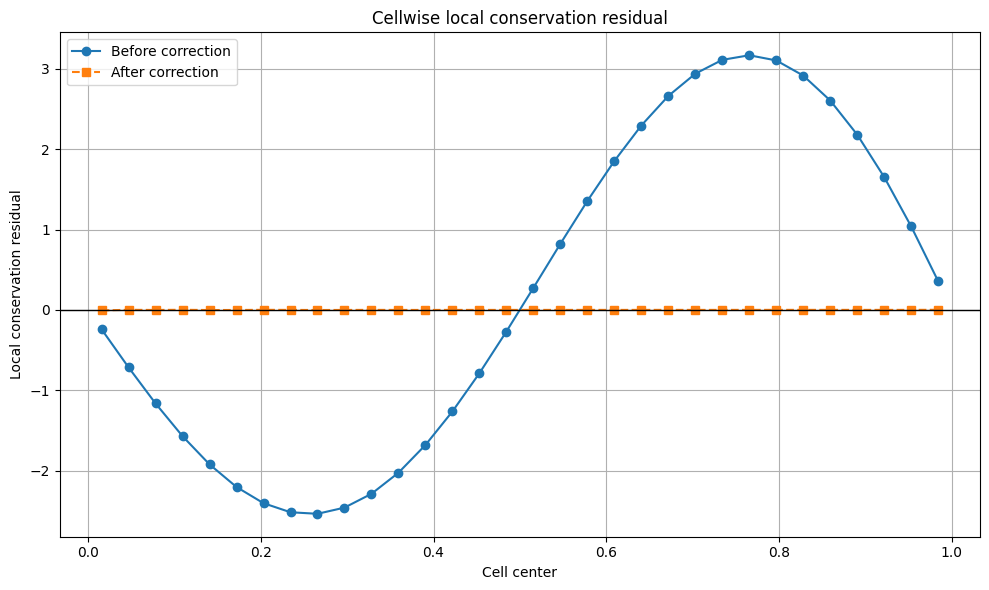

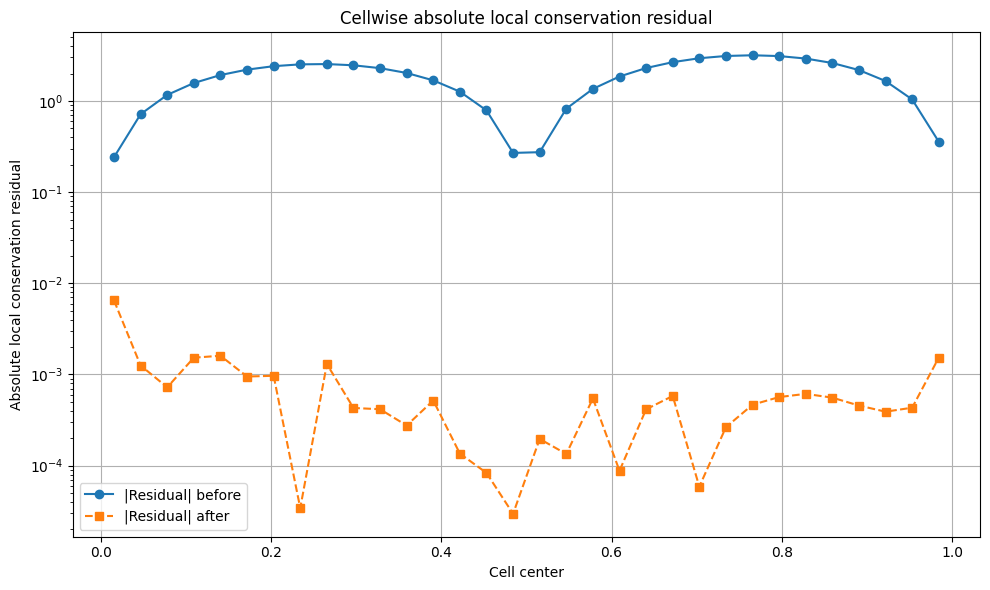

In [9]:
# --------------------------------------------------------
# Local conservation comparison
# --------------------------------------------------------
x_center_b, residual_before, abs_before = compute_local_conservation_before_correction(domain, ph)
x_center_a, residual_after, abs_after = compute_local_conservation_after_correction(domain, ph, model)

if rank == 0:
    print("\nCellwise local conservation summary")
    print(f"max |residual| before = {np.max(abs_before):.6e}")
    print(f"max |residual| after  = {np.max(abs_after):.6e}")
    print(f"mean|residual| before = {np.mean(abs_before):.6e}")
    print(f"mean|residual| after  = {np.mean(abs_after):.6e}")

    plot_local_conservation_comparison(
        x_center_b,
        residual_before,
        residual_after,
        abs_before,
        abs_after,
    )

In [10]:
import basix
def q_exact_np(x):
    """
    Exact Darcy flux for
        p_exact(x) = sin(2*pi*x),
        K(x) = 2 + x^2

    q_exact(x) = -K(x) p_exact'(x)
               = -(2+x^2) * 2*pi*cos(2*pi*x)
    """
    return -(2.0 + x**2) * (2.0 * np.pi * np.cos(2.0 * np.pi * x))


def compute_flux_L2_error_before_after(domain, ph, model, quad_degree=8):
    """
    Compute L2 flux error before and after reconstruction:

        q_raw(x) = -K(x) p_h'(x)
        q_rec(x) = model(x)

    compared with exact flux q_exact(x).

    This version assumes the neural network outputs the FULL
    reconstructed flux, not a correction.

    Works for P1, P2, and higher on a 1D interval mesh.

    Returns on rank 0:
        err_raw, err_rec
    """
    comm = domain.comm
    rank = comm.rank
    tdim = domain.topology.dim

    if tdim != 1:
        raise ValueError("This routine is written for 1D interval meshes only.")

    V = ph.function_space
    uh = ph.x.array

    domain.topology.create_connectivity(tdim, 0)
    c_to_v = domain.topology.connectivity(tdim, 0)
    num_cells_local = domain.topology.index_map(tdim).size_local

    basix_el = V.element.basix_element

    # Quadrature on reference interval [0,1]
    qpts_ref, qw = basix.make_quadrature(basix.CellType.interval, quad_degree)
    xiq = qpts_ref[:, 0]

    # First derivatives of basis at quadrature points
    # tab shape: (nderivs, npoints, ndofs, value_size)
    tab = basix_el.tabulate(1, qpts_ref)
    dphi_dxi = tab[1, :, :, 0]   # shape (nq, ndofs)

    err_raw_sq_local = 0.0
    err_rec_sq_local = 0.0

    model.eval()

    with torch.no_grad():
        for cell in range(num_cells_local):
            cell_dofs = V.dofmap.cell_dofs(cell)
            u_cell = uh[cell_dofs]

            verts = c_to_v.links(cell)
            xv = domain.geometry.x[verts, 0]
            a = np.min(xv)
            b = np.max(xv)
            h = b - a

            if h <= 0:
                raise ValueError(f"Non-positive cell length detected on cell {cell}.")

            # Map quadrature points from reference [0,1] to physical cell [a,b]
            xq = a + h * xiq

            # Evaluate p_h'(xq): dp/dx = (1/h) * dp/dxi
            dpdx_q = (dphi_dxi @ u_cell) / h   # shape (nq,)

            # Raw FE flux
            q_raw = -(2.0 + xq**2) * dpdx_q

            # Reconstructed flux from neural network
            xq_t = torch.tensor(xq.reshape(-1, 1), dtype=torch.float64)
            q_rec = model(xq_t).cpu().numpy().reshape(-1)

            # Exact flux
            q_ex = q_exact_np(xq)

            # Physical integral: ∫_K ... dx = h ∫_[0,1] ... dxi
            err_raw_sq_local += h * np.sum(qw * (q_raw - q_ex) ** 2)
            err_rec_sq_local += h * np.sum(qw * (q_rec - q_ex) ** 2)

    err_raw_sq = comm.reduce(err_raw_sq_local, op=MPI.SUM, root=0)
    err_rec_sq = comm.reduce(err_rec_sq_local, op=MPI.SUM, root=0)

    if rank != 0:
        return None, None

    return np.sqrt(err_raw_sq), np.sqrt(err_rec_sq)

err_flux_raw, err_flux_rec = compute_flux_L2_error_before_after(domain, ph, model)

if MPI.COMM_WORLD.rank == 0:
    print("\nFlux L2 error compared with exact flux q = -K p_exact':")
    print(f"||q_raw - q_exact||_L2 = {err_flux_raw:.10e}")
    print(f"||q_rec - q_exact||_L2 = {err_flux_rec:.10e}")


Flux L2 error compared with exact flux q = -K p_exact':
||q_raw - q_exact||_L2 = 5.8798483344e-01
||q_rec - q_exact||_L2 = 2.1869022606e-03
